# Import All Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import math
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Load Dataset

In [18]:
df = pd.read_csv("/content/data.csv", engine="python", on_bad_lines="skip")

print("Dataset loaded successfully")
print(f"Shape          : {df.shape}")
print(f"Total rows     : {df.shape[0]}")
print(f"Total columns  : {df.shape[1]}")
print(f"\nMissing values :\n{df.isnull().sum()}")
print(f"\nClass distribution :\n{df['strength'].value_counts()}")
print(f"\nSample data :")
df.head()

Dataset loaded successfully
Shape          : (669640, 2)
Total rows     : 669640
Total columns  : 2

Missing values :
password    1
strength    0
dtype: int64

Class distribution :
strength
1    496801
0     89702
2     83137
Name: count, dtype: int64

Sample data :


,password,strength
0,kzde5577,1
1,kino3434,1
2,visi7k1yr,1
3,megzy123,1
4,lamborghin1,1


# Data Cleaning

In [19]:
before = df.shape[0]

# Remove missing values
df = df.dropna()
print(f"After removing nulls        : {df.shape[0]} rows")

# Remove duplicates
df = df.drop_duplicates()
print(f"After removing duplicates   : {df.shape[0]} rows")

# Strip whitespace
df["password"] = df["password"].str.strip()
print(f"Whitespace stripped")

# Remove very short passwords
df = df[df["password"].str.len() >= 4]
print(f"After removing short (<4)   : {df.shape[0]} rows")

# Keep only passwords between 4 and 16 characters
df = df[df["password"].str.len().between(4, 16)]
print(f"After length filter (4-16)  : {df.shape[0]} rows")

# Remove all-digit passwords
df = df[~df["password"].str.match(r'^[0-9]+$')]
print(f"After removing all-digit    : {df.shape[0]} rows")

# Remove all-letter passwords
df = df[~df["password"].str.match(r'^[a-zA-Z]+$')]
print(f"After removing all-letter   : {df.shape[0]} rows")

# Remove repeated character passwords
df = df[~df["password"].str.match(r'^(.)\1+$')]
print(f"After removing repeated     : {df.shape[0]} rows")

after = df.shape[0]
print(f"\nTotal rows removed : {before - after}")
print(f"Final dataset size : {after} rows")

After removing nulls        : 669639 rows
After removing duplicates   : 669639 rows
Whitespace stripped
After removing short (<4)   : 669601 rows
After length filter (4-16)  : 662793 rows
After removing all-digit    : 662688 rows
After removing all-letter   : 662388 rows
After removing repeated     : 662377 rows

Total rows removed : 7263
Final dataset size : 662377 rows


# Feature Extraction

In [20]:

# --- Feature 1 to 6: Character composition ---
def extract_features(p):
    return pd.Series({
        "length"      : len(p),
        "upper"       : sum(1 for c in p if c.isupper()),
        "lower"       : sum(1 for c in p if c.islower()),
        "digits"      : sum(1 for c in p if c.isdigit()),
        "special"     : len(re.findall(r'[^a-zA-Z0-9]', p)),
        "unique_chars": len(set(p)),
    })

features = df["password"].apply(extract_features)
df = pd.concat([df, features], axis=1)
print("Character features extracted — length, upper, lower, digits, special, unique_chars")

# --- Feature 7: Shannon Entropy ---
def calculate_entropy(p):
    prob = [p.count(c) / len(p) for c in set(p)]
    return -sum([x * math.log2(x) for x in prob])

df["entropy"] = df["password"].apply(calculate_entropy)
print("Entropy feature extracted")

# --- Feature 8: Sequence Detection ---
def has_sequence(p):
    sequences = ["123", "234", "345", "abc", "bcd", "cde"]
    return int(any(seq in p.lower() for seq in sequences))

df["has_sequence"] = df["password"].apply(has_sequence)
print("Sequence detection feature extracted")

# --- Feature 9: Common Pattern Detection ---
common_patterns = ["password", "admin", "qwerty", "letmein",
                   "welcome", "1234", "12345", "abc123", "iloveyou"]

def check_common(p):
    return int(any(pattern in p.lower() for pattern in common_patterns))

df["common_pattern"] = df["password"].apply(check_common)
print("Common pattern feature extracted")

print(f"\nTotal features extracted : 9")
print(f"Dataset shape now        : {df.shape}")
print(f"\nFeature preview :")
df.head()

Character features extracted — length, upper, lower, digits, special, unique_chars
Entropy feature extracted
Sequence detection feature extracted
Common pattern feature extracted

Total features extracted : 9
Dataset shape now        : (662377, 11)

Feature preview :


,password,strength,length,upper,lower,digits,special,unique_chars,entropy,has_sequence,common_pattern
0,kzde5577,1,8,0,4,4,0,6,2.500000,0,0
1,kino3434,1,8,0,4,4,0,6,2.500000,0,0
2,visi7k1yr,1,9,0,7,2,0,8,2.947703,0,0
3,megzy123,1,8,0,5,3,0,8,3.000000,1,0
4,lamborghin1,1,11,0,10,1,0,11,3.459432,0,0


# Exploratory Data Analysis(EDA)/Visualization

DataFrame shape: (662377, 11)
Columns: ['password', 'strength', 'length', 'upper', 'lower', 'digits', 'special', 'unique_chars', 'entropy', 'has_sequence', 'common_pattern']
After cleaning: 662377 rows remaining


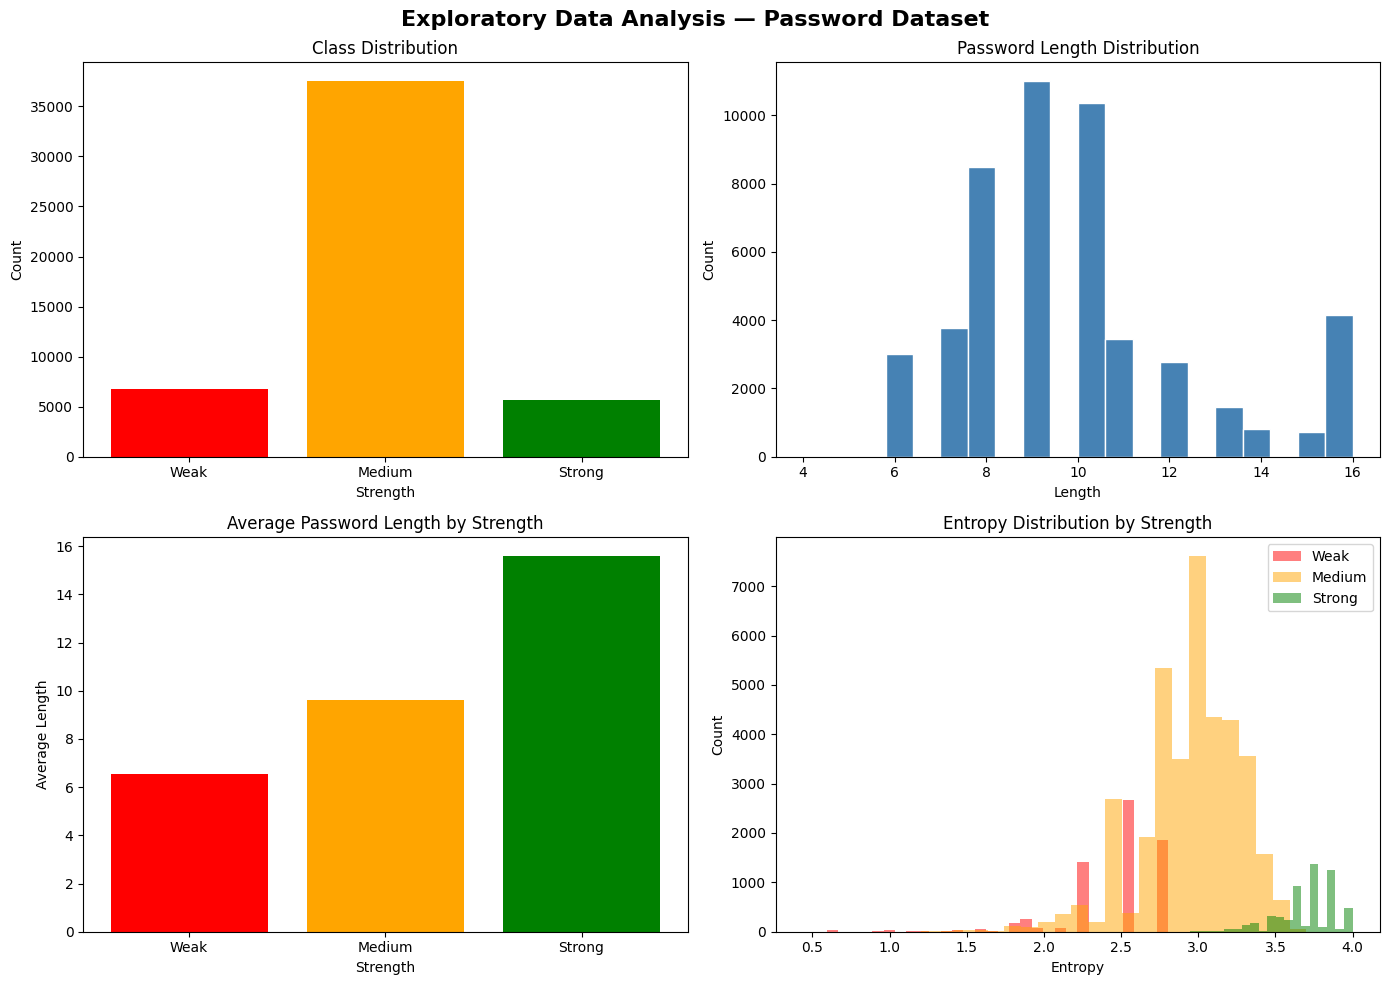

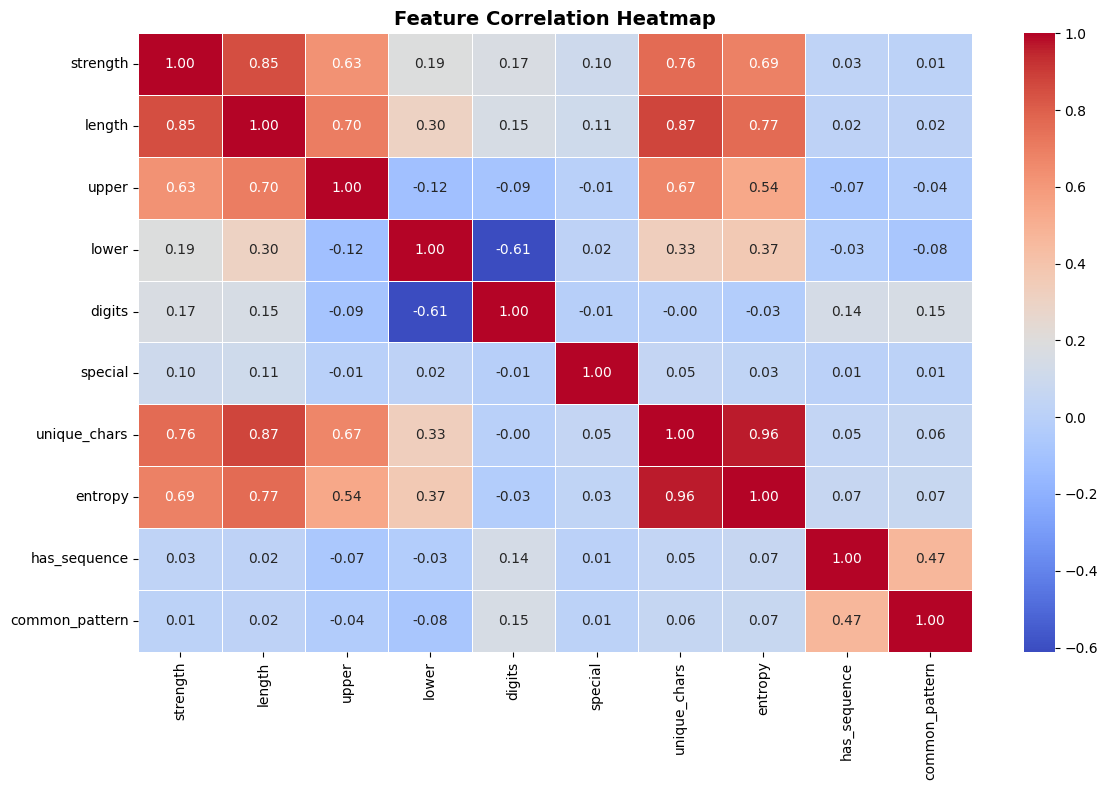

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is a DataFrame
if not isinstance(df, pd.DataFrame):
    print(f"Converting {type(df)} to DataFrame")
    try:
        df = pd.DataFrame(df)
    except Exception as e:
        print(f"Could not convert to DataFrame: {e}")
        raise

print(f"DataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Handle the length column
if 'length' in df.columns:
    # Convert to numeric safely
    try:
        df['length'] = pd.to_numeric(df['length'], errors='coerce')
    except TypeError as e:
        print(f"Error converting to numeric: {e}")
        # Alternative approach - convert each element
        df['length'] = df['length'].apply(lambda x: pd.to_numeric(x, errors='coerce'))
else:
    print("'length' column not found. Creating from 'password' if available...")
    if 'password' in df.columns:
        df['length'] = df['password'].astype(str).str.len()
    else:
        print("No password column found. Creating dummy length column...")
        # Create a dummy length column if needed
        df['length'] = 0

# Drop NaN values in critical columns
critical_cols = ['length', 'strength', 'entropy']
existing_critical = [col for col in critical_cols if col in df.columns]
df_clean = df.dropna(subset=existing_critical)

print(f"After cleaning: {df_clean.shape[0]} rows remaining")

# Sample from the cleaned dataframe
sample_size = min(50000, len(df_clean))
sample_df = df_clean.sample(sample_size, random_state=42)

# Now create the visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Exploratory Data Analysis — Password Dataset", fontsize=16, fontweight='bold')

# Chart 1 — Class distribution
if 'strength' in sample_df.columns:
    class_counts = sample_df["strength"].value_counts().sort_index()
    axes[0, 0].bar(["Weak", "Medium", "Strong"], class_counts,
                   color=["red", "orange", "green"])
    axes[0, 0].set_title("Class Distribution")
    axes[0, 0].set_xlabel("Strength")
    axes[0, 0].set_ylabel("Count")

# Chart 2 — Password length distribution
if 'length' in sample_df.columns:
    axes[0, 1].hist(sample_df["length"], bins=20, color="steelblue", edgecolor="white")
    axes[0, 1].set_title("Password Length Distribution")
    axes[0, 1].set_xlabel("Length")
    axes[0, 1].set_ylabel("Count")

# Chart 3 — Average length per strength class
if 'strength' in sample_df.columns and 'length' in sample_df.columns:
    avg_length = sample_df.groupby("strength")["length"].mean()
    axes[1, 0].bar(["Weak", "Medium", "Strong"], avg_length,
                   color=["red", "orange", "green"])
    axes[1, 0].set_title("Average Password Length by Strength")
    axes[1, 0].set_xlabel("Strength")
    axes[1, 0].set_ylabel("Average Length")

# Chart 4 — Entropy distribution by class
if 'entropy' in sample_df.columns and 'strength' in sample_df.columns:
    for strength, label, color in zip([0, 1, 2],
                                       ["Weak", "Medium", "Strong"],
                                       ["red", "orange", "green"]):
        subset = sample_df[sample_df["strength"] == strength]["entropy"]
        if len(subset) > 0:
            axes[1, 1].hist(subset, bins=30, alpha=0.5, label=label, color=color)
    axes[1, 1].set_title("Entropy Distribution by Strength")
    axes[1, 1].set_xlabel("Entropy")
    axes[1, 1].set_ylabel("Count")
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Chart 5 — Correlation Heatmap
if len(sample_df.select_dtypes(include=['float64', 'int64']).columns) > 1:
    plt.figure(figsize=(12, 8))
    numeric_cols = sample_df.select_dtypes(include=['float64', 'int64']).columns
    sns.heatmap(sample_df[numeric_cols].corr(), annot=True, fmt=".2f",
               cmap="coolwarm", linewidths=0.5)
    plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap")

# Save Cleaned Dataset

In [22]:

# Move strength to last column
cols = [col for col in df.columns if col != "strength"] + ["strength"]
df = df[cols]

df.to_csv("cleaned_password_dataset.csv", index=False)

print("Cleaned dataset saved successfully")
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Cleaned dataset saved successfully
Shape  : (662377, 11)
Columns: ['password', 'length', 'upper', 'lower', 'digits', 'special', 'unique_chars', 'entropy', 'has_sequence', 'common_pattern', 'strength']


# Model Training

In [23]:

df = pd.read_csv("/content/cleaned_password_dataset.csv")

X = df.drop(columns=["password", "strength"])
y = df["strength"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples   : {X_train.shape[0]}")
print(f"Testing samples    : {X_test.shape[0]}")
print(f"Features used      : {X.columns.tolist()}")

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"\nModel trained successfully")
print(f"Test Accuracy : {accuracy_score(y_test, y_pred) * 100:.4f}%")

Training samples   : 529901
Testing samples    : 132476
Features used      : ['length', 'upper', 'lower', 'digits', 'special', 'unique_chars', 'entropy', 'has_sequence', 'common_pattern']

Model trained successfully
Test Accuracy : 99.9970%


# Model Evaluation
Evaluating the Random Forest model using multiple metrics:
- Accuracy
- Precision, Recall, F1 Score
- Confusion Matrix
- Training vs Validation Accuracy
- Prediction Confidence

# Classification Report

In [24]:

print("=" * 60)
print("       RANDOM FOREST — CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred,
      target_names=["Weak", "Medium", "Strong"]))

       RANDOM FOREST — CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Weak       1.00      1.00      1.00     17877
      Medium       1.00      1.00      1.00     99310
      Strong       1.00      1.00      1.00     15289

    accuracy                           1.00    132476
   macro avg       1.00      1.00      1.00    132476
weighted avg       1.00      1.00      1.00    132476



# Confusion Matrix

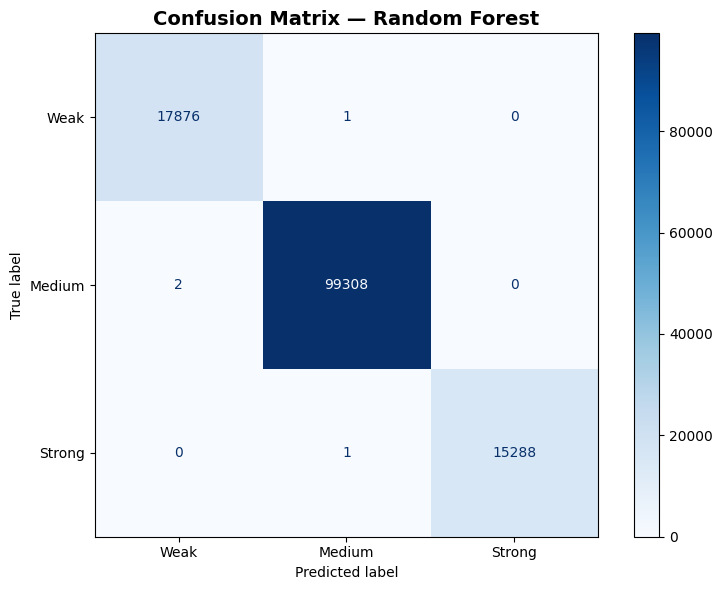

In [25]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Weak", "Medium", "Strong"])

plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues", ax=plt.gca())
plt.title("Confusion Matrix — Random Forest", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Training vs Validation Accuracy

  Training Accuracy   : 99.9992%
  Validation Accuracy : 99.9970%
  Difference          : 0.0023%
  Model is NOT overfitting
  Training and validation accuracy are very close


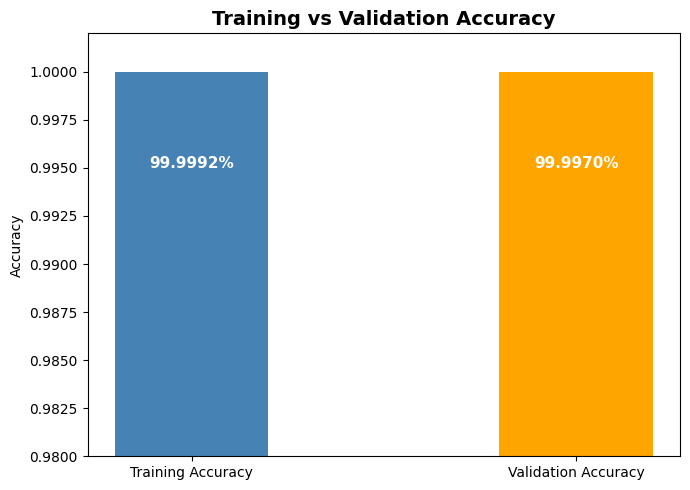

In [26]:
train_accuracy = model.score(X_train, y_train)
test_accuracy  = model.score(X_test, y_test)

print("=" * 50)
print(f"  Training Accuracy   : {train_accuracy * 100:.4f}%")
print(f"  Validation Accuracy : {test_accuracy * 100:.4f}%")
print(f"  Difference          : {(train_accuracy - test_accuracy) * 100:.4f}%")
print("=" * 50)

if (train_accuracy - test_accuracy) < 0.01:
    print("  Model is NOT overfitting")
    print("  Training and validation accuracy are very close")
else:
    print("  Model may be overfitting")
    print("  Large gap between training and validation accuracy")
print("=" * 50)

# Bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar(["Training Accuracy", "Validation Accuracy"],
               [train_accuracy, test_accuracy],
               color=["steelblue", "orange"], width=0.4)
for bar, val in zip(bars, [train_accuracy, test_accuracy]):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() - 0.005,
             f"{val * 100:.4f}%",
             ha="center", fontsize=11, color="white", fontweight='bold')
plt.title("Training vs Validation Accuracy", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy")
plt.ylim(0.98, 1.002)
plt.tight_layout()
plt.show()

#  Training and Validation Curve

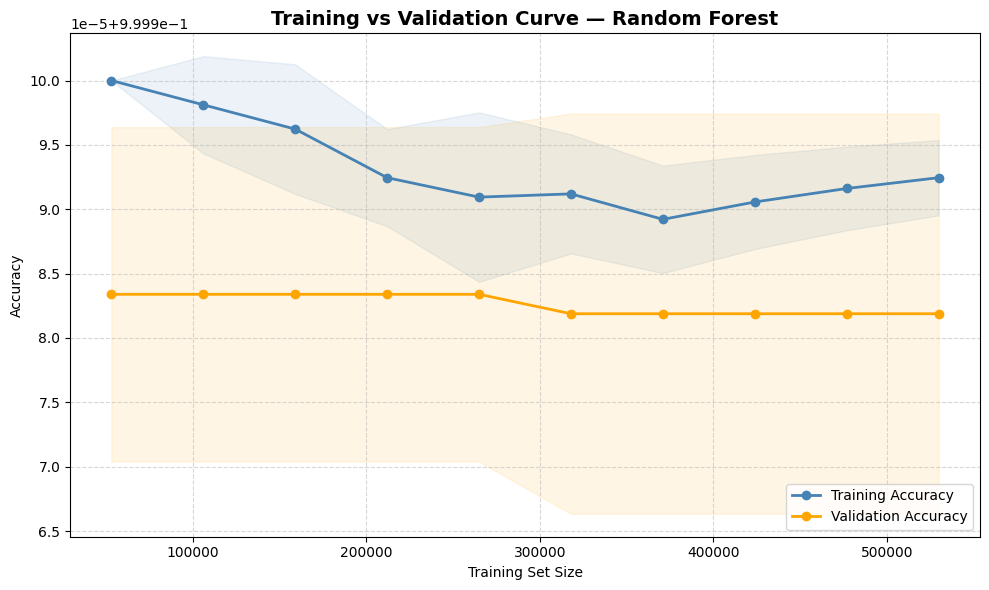

In [27]:
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X, y,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue',
         label='Training Accuracy', linewidth=2)
plt.plot(train_sizes, val_mean,   'o-', color='orange',
         label='Validation Accuracy', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.1, color='steelblue')
plt.fill_between(train_sizes, val_mean - val_std,
                 val_mean + val_std, alpha=0.1, color='orange')
plt.title("Training vs Validation Curve — Random Forest",
          fontsize=14, fontweight='bold')
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Prediction Confidence

In [28]:
y_prob = model.predict_proba(X_test)

confidence_df = pd.DataFrame(y_prob, columns=["Weak %", "Medium %", "Strong %"])
confidence_df[["Weak %", "Medium %", "Strong %"]] *= 100
confidence_df["Predicted"] = ["Weak" if p == 0 else
                               "Medium" if p == 1 else
                               "Strong" for p in y_pred]
confidence_df["Confidence %"] = confidence_df[["Weak %", "Medium %", "Strong %"]].max(axis=1)

print("Prediction Confidence — First 10 samples:")
print(confidence_df.head(10).to_string(index=False))

print(f"\nAverage Confidence per Class:")
print(f"  Weak   : {y_prob[:, 0].mean() * 100:.2f}%")
print(f"  Medium : {y_prob[:, 1].mean() * 100:.2f}%")
print(f"  Strong : {y_prob[:, 2].mean() * 100:.2f}%")
print(f"\nOverall Average Confidence : {confidence_df['Confidence %'].mean():.2f}%")

Prediction Confidence — First 10 samples:
 Weak %  Medium %  Strong % Predicted  Confidence %
    0.0     100.0       0.0    Medium         100.0
  100.0       0.0       0.0      Weak         100.0
    0.0     100.0       0.0    Medium         100.0
    0.0     100.0       0.0    Medium         100.0
    0.0     100.0       0.0    Medium         100.0
    0.0     100.0       0.0    Medium         100.0
    0.0     100.0       0.0    Medium         100.0
    0.0     100.0       0.0    Medium         100.0
    0.0     100.0       0.0    Medium         100.0
    0.0     100.0       0.0    Medium         100.0

Average Confidence per Class:
  Weak   : 13.49%
  Medium : 74.96%
  Strong : 11.54%

Overall Average Confidence : 100.00%


# Feature Importance

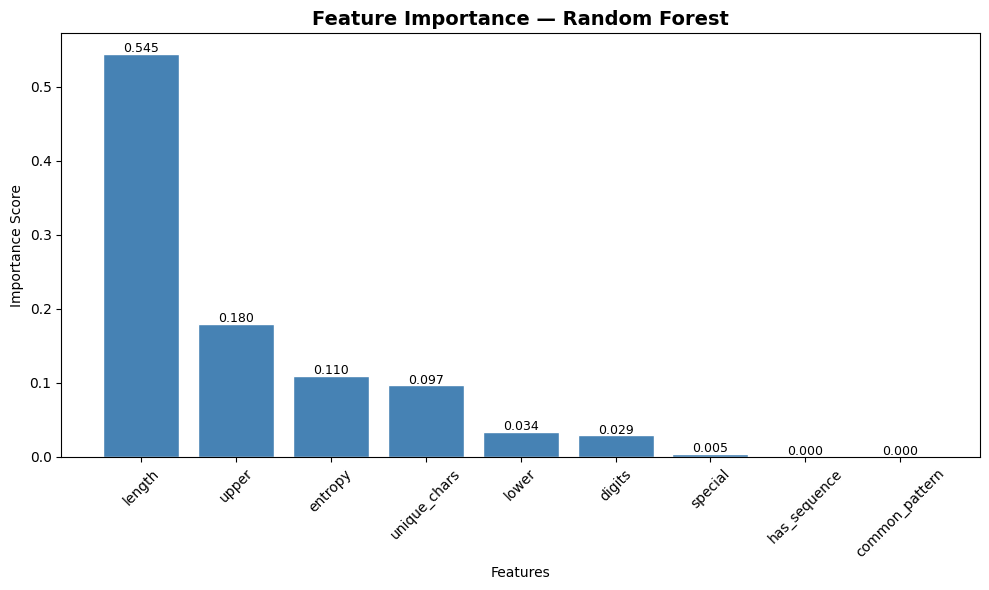


Feature Importance Ranking:
  1. length          : 0.5451
  2. upper           : 0.1800
  3. entropy         : 0.1099
  4. unique_chars    : 0.0966
  5. lower           : 0.0340
  6. digits          : 0.0295
  7. special         : 0.0045
  8. has_sequence    : 0.0003
  9. common_pattern  : 0.0002


In [29]:
feature_names      = X.columns.tolist()
importances        = model.feature_importances_
indices            = np.argsort(importances)[::-1]
sorted_features    = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 6))
bars = plt.bar(sorted_features, sorted_importances, color='steelblue', edgecolor='white')
for bar, val in zip(bars, sorted_importances):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002,
             f"{val:.3f}",
             ha="center", fontsize=9)
plt.title("Feature Importance — Random Forest",
          fontsize=14, fontweight='bold')
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for i, (f, v) in enumerate(zip(sorted_features, sorted_importances), 1):
    print(f"  {i}. {f:15s} : {v:.4f}")

## STEP 9 — PASSWORD FEEDBACK SYSTEM
A function that takes any password, extracts its features,
runs it through the trained model, and returns:
- Strength classification (Weak / Medium / Strong)
- Confidence scores per class
- Actionable improvement suggestions

In [30]:
def analyze_password(password):
    features = [extract_features(password)]

    prediction = model.predict(features)[0]
    confidence = model.predict_proba(features)[0]

    strength   = {0: "WEAK", 1: "MEDIUM", 2: "STRONG"}[prediction]
    color_map  = {"WEAK": "❌", "MEDIUM": "⚠️", "STRONG": "✅"}

    length, upper, lower, digits, special, unique_chars, entropy = features[0]

    sequences       = ["123", "234", "345", "abc", "bcd", "cde"]
    common_patterns = ["password", "admin", "qwerty", "letmein",
                       "welcome", "1234", "12345", "abc123", "iloveyou"]

    has_seq    = int(any(seq in password.lower() for seq in sequences))
    common_pat = int(any(pat in password.lower() for pat in common_patterns))

    feedback = []
    if length < 8:
        feedback.append("Too short — use at least 8 characters")
    if upper == 0:
        feedback.append("Add at least one uppercase letter (A-Z)")
    if lower == 0:
        feedback.append("Add at least one lowercase letter (a-z)")
    if digits == 0:
        feedback.append("Add at least one digit (0-9)")
    if special == 0:
        feedback.append("Add at least one special character (!@#$%)")
    if has_seq:
        feedback.append("Avoid sequential patterns like 123 or abc")
    if common_pat:
        feedback.append("Avoid common words like password, admin, qwerty")
    if entropy < 2.5:
        feedback.append("Too predictable — use more varied characters")

    print("=" * 55)
    print(f"  Password         : {password}")
    print(f"  Strength         : {color_map[strength]} {strength}")
    print(f"  Confidence       : {max(confidence) * 100:.2f}%")
    print(f"    Weak           : {confidence[0] * 100:.2f}%")
    print(f"    Medium         : {confidence[1] * 100:.2f}%")
    print(f"    Strong         : {confidence[2] * 100:.2f}%")
    print("-" * 55)
    print(f"  Length           : {length}")
    print(f"  Uppercase        : {upper}")
    print(f"  Lowercase        : {lower}")
    print(f"  Digits           : {digits}")
    print(f"  Special chars    : {special}")
    print(f"  Unique chars     : {unique_chars}")
    print(f"  Entropy          : {entropy:.2f} bits")
    print("-" * 55)

    if feedback:
        print("  Suggestions:")
        for i, tip in enumerate(feedback, 1):
            print(f"    {i}. {tip}")
    else:
        print("  Great password! No improvements needed.")

    print("=" * 55)
    print()


##SAVE MODEL
Saving the trained Random Forest model as model.pkl
and feature names as feature_names.json
for use in the FastAPI backend.

In [31]:
# Save trained model
joblib.dump(model, "model.pkl")
print("model.pkl saved successfully")

# Save feature names
feature_names = X.columns.tolist()
with open("feature_names.json", "w") as f:
    json.dump(feature_names, f)
print("feature_names.json saved successfully")

print(f"\nFeatures : {feature_names}")

model.pkl saved successfully
feature_names.json saved successfully

Features : ['length', 'upper', 'lower', 'digits', 'special', 'unique_chars', 'entropy', 'has_sequence', 'common_pattern']
